# Exploratory Data Analysis (EDA) - Telco Customer Churn

This notebook conducts a detailed Exploratory Data Analysis on the Telco Customer Churn dataset to understand the business problem and extract insights that will guide preprocessing, feature engineering, and modeling.

## Objectives:
- Load and inspect the dataset structure, shape, and column types.
- Identify and handle missing or malformed values (specifically the blank values in `TotalCharges`).
- Analyze the target class distribution (class imbalance).
- Visualize relations between demographic, service-related, and financial variables with respect to Churn.
- Provide clear business insights from each visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 6)

--- 
## 1. Load the Dataset & Inspect Structure

In [2]:
# Load data
data_path = '../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(data_path)

# Display shape
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

# Show columns information
df.info()

Dataset Shape: 7043 rows, 21 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Pape

In [3]:
# Inspect the first few rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


--- 
## 2. Check for Missing and Malformed Values

Let's look for standard missing values (NaNs) and non-standard missing values (like empty strings or whitespaces in string columns representing numbers, specifically `TotalCharges`).

In [4]:
# Standard missing values
print("Standard missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("None found standardly.\n")

# Check for whitespaces in TotalCharges
empty_total_charges = (df['TotalCharges'].str.strip() == '').sum()
print(f"Number of records with empty/whitespace TotalCharges: {empty_total_charges}")

Standard missing values per column:
Series([], dtype: int64)
None found standardly.

Number of records with empty/whitespace TotalCharges: 11


Let's examine the records where `TotalCharges` is empty. We notice that they correspond to customers with `tenure = 0` (new customers who joined this month and haven't been billed yet).

In [5]:
# Show records with empty TotalCharges
df[df['TotalCharges'].str.strip() == ''][['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,,No
753,0,20.25,,No
936,0,80.85,,No
1082,0,25.75,,No
1340,0,56.05,,No
3331,0,19.85,,No
3826,0,25.35,,No
4380,0,20.00,,No
5218,0,19.70,,No
6670,0,73.35,,No


### Data Cleaning Action
1. Replace empty spaces with `NaN`.
2. Convert `TotalCharges` column to float type.
3. Fill `NaN` values with `0` (since these are new customers with 0 tenure, their total accumulated charges should naturally be 0).

In [6]:
# Clean TotalCharges
df['TotalCharges'] = df['TotalCharges'].replace(r'^\s*$', np.nan, regex=True)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)

# Verify data type
print(f"TotalCharges dtype after cleaning: {df['TotalCharges'].dtype}")
print(f"Missing values remaining: {df['TotalCharges'].isnull().sum()}")

TotalCharges dtype after cleaning: float64
Missing values remaining: 0


--- 
## 3. Check Class Imbalance

Analyzing the target column `Churn` determines if we are dealing with class imbalance.

Churn Value Counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentages:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


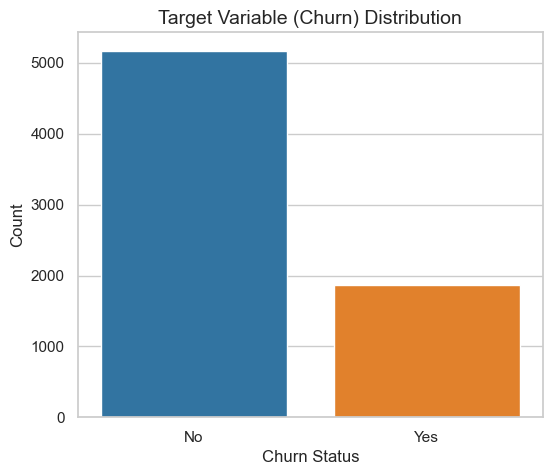

In [7]:
churn_counts = df['Churn'].value_counts()
churn_percentages = df['Churn'].value_counts(normalize=True) * 100

print("Churn Value Counts:")
print(churn_counts)
print("\nChurn Percentages:")
print(churn_percentages)

# Plot Target Distribution
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='Churn', hue='Churn', palette=['#1f77b4', '#ff7f0e'], legend=False)
plt.title('Target Variable (Churn) Distribution', fontsize=14)
plt.ylabel('Count')
plt.xlabel('Churn Status')
plt.show()

### 💡 Insight: Class Imbalance
- **Retention (No Churn):** ~73.5% (5,174 customers)
- **Attrition (Churn):** ~26.5% (1,869 customers)
- **Takeaway:** There is a moderate class imbalance. If we build a dummy model that always predicts 'No Churn', we would achieve ~73.5% accuracy. Therefore, **Accuracy** alone is not a sufficient metric. We should optimize for **Precision**, **Recall**, and **ROC-AUC** to ensure we accurately flag churning customers without excessive false alarms.

--- 
## 4. Visualizations & Business Insights

Let's explore how other variables relate to customer churn.

### 4.1 Numerical Features (Tenure and Monthly Charges)
Let's examine how customer tenure (how long they have stayed) and monthly billing amounts influence churn.

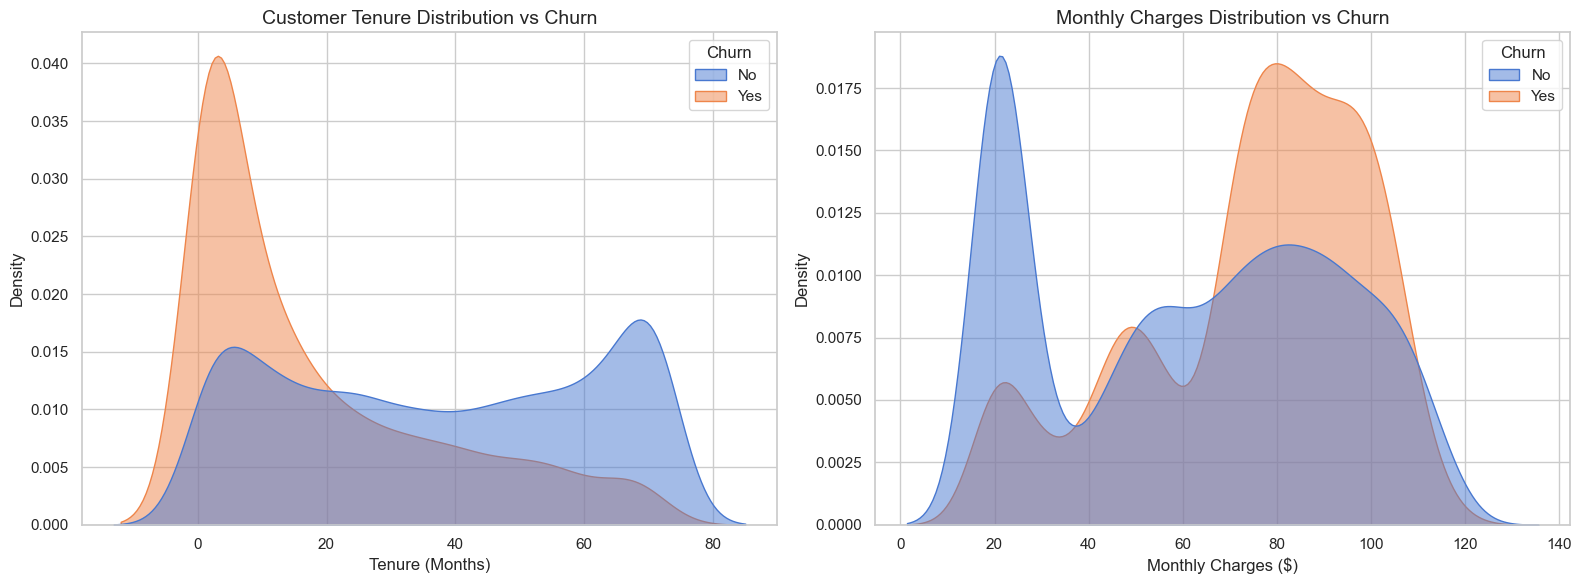

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Tenure Distribution
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, common_norm=False, alpha=0.5, ax=axes[0])
axes[0].set_title('Customer Tenure Distribution vs Churn', fontsize=14)
axes[0].set_xlabel('Tenure (Months)')
axes[0].set_ylabel('Density')

# Monthly Charges Distribution
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True, common_norm=False, alpha=0.5, ax=axes[1])
axes[1].set_title('Monthly Charges Distribution vs Churn', fontsize=14)
axes[1].set_xlabel('Monthly Charges ($)')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.show()

### 💡 Insights: Tenure & Monthly Charges
- **Tenure:** The churn density is extremely high for new customers (tenure < 5 months). Conversely, long-term customers (tenure > 60 months) have very high retention rates. This suggests that retention efforts should be heavily concentrated in the **first few months** of a customer's subscription lifecycle.
- **Monthly Charges:** Customers who churn tend to have higher monthly charges. The churn density peaks around $70 - $100. Customers with lower monthly charges (around $20, typically phone-only subscriptions) are far less likely to churn. High-priced tiers might be driving customers away to competitors.

### 4.2 Contract Type vs. Churn
Contract types include Month-to-month, One year, and Two year. Let's see how they impact churn.

<Figure size 1000x600 with 0 Axes>

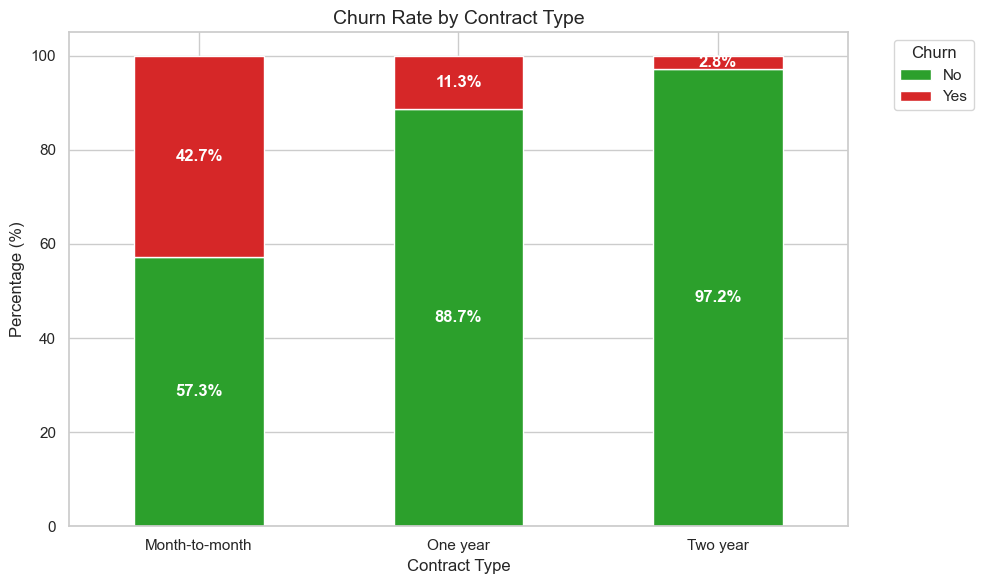

In [9]:
plt.figure(figsize=(10, 6))
contract_churn = df.groupby(['Contract', 'Churn']).size().unstack(fill_value=0)
contract_churn_pct = contract_churn.div(contract_churn.sum(axis=1), axis=0) * 100

ax = contract_churn_pct.plot(kind='bar', stacked=True, color=['#2ca02c', '#d62728'], figsize=(10, 6))
plt.title('Churn Rate by Contract Type', fontsize=14)
plt.ylabel('Percentage (%)')
plt.xlabel('Contract Type')
plt.xticks(rotation=0)
plt.legend(title='Churn', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add values inside the bars
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 0:
        ax.annotate(f'{height:.1f}%', (x + width/2, y + height/2), ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

### 💡 Insight: Contract Type
- **Month-to-month contracts:** Over **42.7%** of month-to-month contract customers churn within this period.
- **Long-term contracts:** One-year contracts show an **11.3%** churn rate, while two-year contracts have a negligible **2.8%** churn rate.
- **Takeaway:** Month-to-month contracts are highly volatile. Incentivizing users to switch to 1 or 2-year contracts (even with small discount incentives) will dramatically improve customer retention.

### 4.3 Internet Service Type vs. Churn
Let's analyze churn based on the type of internet service subscribed (DSL, Fiber optic, or No Internet).

<Figure size 1000x600 with 0 Axes>

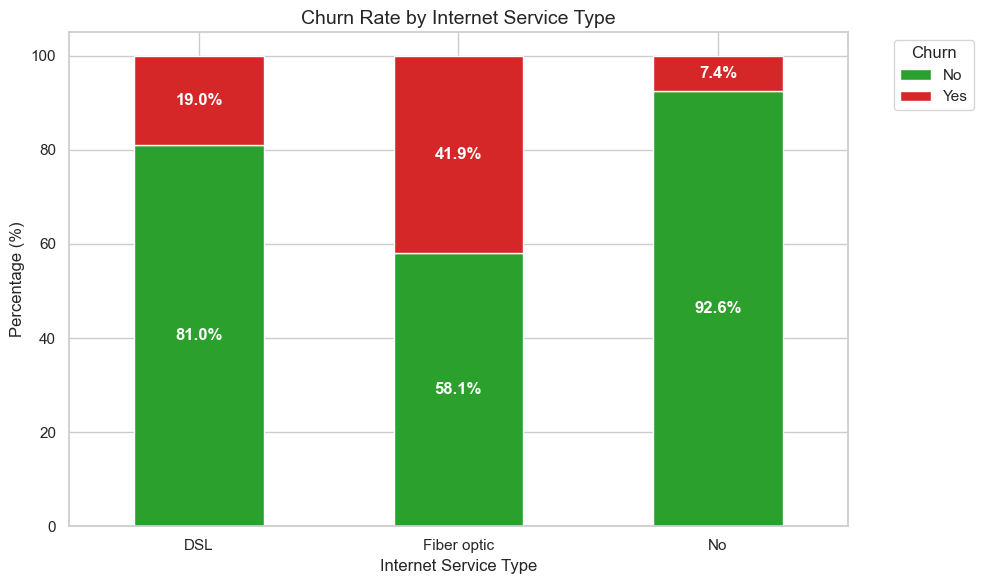

In [10]:
plt.figure(figsize=(10, 6))
internet_churn = df.groupby(['InternetService', 'Churn']).size().unstack(fill_value=0)
internet_churn_pct = internet_churn.div(internet_churn.sum(axis=1), axis=0) * 100

ax = internet_churn_pct.plot(kind='bar', stacked=True, color=['#2ca02c', '#d62728'], figsize=(10, 6))
plt.title('Churn Rate by Internet Service Type', fontsize=14)
plt.ylabel('Percentage (%)')
plt.xlabel('Internet Service Type')
plt.xticks(rotation=0)
plt.legend(title='Churn', bbox_to_anchor=(1.05, 1), loc='upper left')

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 0:
        ax.annotate(f'{height:.1f}%', (x + width/2, y + height/2), ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

### 💡 Insight: Internet Service Type
- **Fiber Optic:** Customers with Fiber Optic service experience an alarmingly high churn rate of **41.9%**.
- **DSL:** Customers with DSL have a much lower churn rate of **19.0%**.
- **No Internet:** Customers who only have phone services have a very low churn rate of **7.4%**.
- **Takeaway:** Fiber optic customers are churning at more than double the rate of DSL customers. The business should investigate: 
  1. Is the pricing of fiber optic too high compared to DSL?
  2. Are there technical/reliability issues or poor service quality with the fiber network?

### 4.4 Impact of Security & Tech Support Add-ons
Let's see if customers with supplementary services like `OnlineSecurity` and `TechSupport` are less prone to churn.

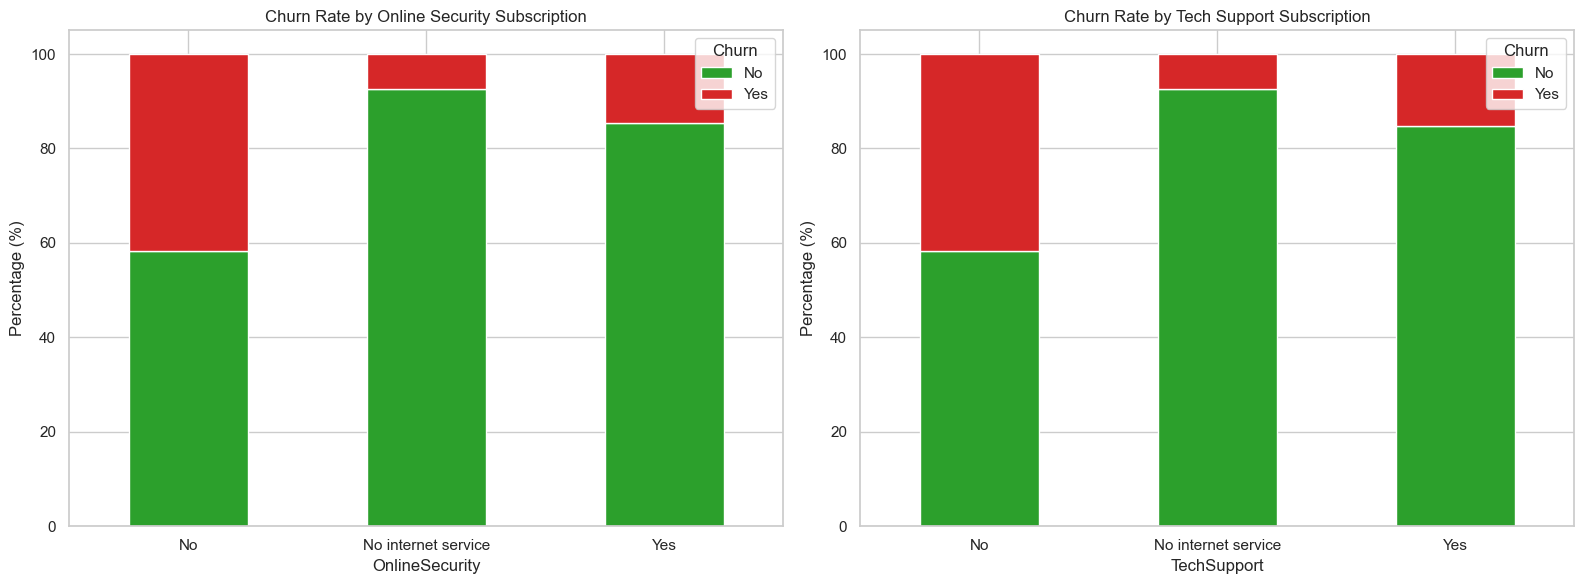

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Online Security vs Churn
security_churn = df.groupby(['OnlineSecurity', 'Churn']).size().unstack(fill_value=0)
security_churn_pct = security_churn.div(security_churn.sum(axis=1), axis=0) * 100
security_churn_pct.plot(kind='bar', stacked=True, color=['#2ca02c', '#d62728'], ax=axes[0])
axes[0].set_title('Churn Rate by Online Security Subscription', fontsize=12)
axes[0].set_ylabel('Percentage (%)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Tech Support vs Churn
support_churn = df.groupby(['TechSupport', 'Churn']).size().unstack(fill_value=0)
support_churn_pct = support_churn.div(support_churn.sum(axis=1), axis=0) * 100
support_churn_pct.plot(kind='bar', stacked=True, color=['#2ca02c', '#d62728'], ax=axes[1])
axes[1].set_title('Churn Rate by Tech Support Subscription', fontsize=12)
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

### 💡 Insight: Security & Tech Support
- Customers who **do not have** Online Security or Tech Support have a much higher churn rate (around **41.7%** and **41.6%** respectively).
- Customers who **have** these services are highly retained (only **14.6%** and **15.2%** churn respectively).
- **Takeaway:** Value-added services such as Tech Support and Online Security create a 'stickier' customer experience, significantly boosting retention. Upselling or bundling these services into base plans (especially for fiber optic users) could be an effective retention strategy.

--- 
## 5. Summary of Key EDA Findings & Next Steps

### Core Findings:
1. **First-Month Volatility:** A large proportion of churned customers cancel within their first 5 months. We need to target new acquisitions early.
2. **Contract Type:** Month-to-month contract holders represent the highest churn risk. Long-term contract locks are highly effective barriers against churn.
3. **High Charges & Fiber Optic:** Fiber optic customers and high-paying tiers churn at double the rate. This points to potential price-value gap issues or service dissatisfaction.
4. **Value-Added Service Bundles:** Adding Online Security and Tech Support correlates heavily with lower churn.

### Actionable modeling recommendations:
- **Class Imbalance:** Use stratified K-Fold splits for evaluation. Optimize models using **ROC-AUC** or **Recall** (to find as many churners as possible).
- **Preprocessing:** drop `customerID`. Convert categorical columns to numeric via One-Hot encoding. Scale numeric columns (`tenure`, `MonthlyCharges`, `TotalCharges`).
- **Baseline Models:** Train Logistic Regression (interpretable baseline) and Random Forest (non-linear classifier).